# Causal Archetypes: PCI vs SHAP on Overdetermination, Preemption, and Irrelevance

> Summary. A synthetic structural causal model (SCM) displays three causal archetypes
> (linear necessary-and-sufficient, overdetermined-not-necessary, preempted) and an
> irrelevance control. We run PCI's necessity / sufficiency machinery on two contrasting
> factual observations and compare it against marginal SHAP and causal SHAP on the same
> model. Two methodological points follow: SHAP returns a single number per feature, while
> PCI's score splits into necessity and sufficiency, letting it distinguish the archetypes;
> and placing every suspect at its own prior mean empties SHAP's attribution budget, while
> PCI's judgments continue to track the causal structure.
> 
## Motivation

Feature-attribution methods such as SHAP summarise each feature's contribution to a
prediction with a single number. That number conflates two questions the causal literature
keeps apart: *would the outcome have been different without this feature?* (**necessity**)
and *does this feature's value, on its own, lock the outcome in?* (**sufficiency**). Classic
actual-causation puzzles are precisely where the two questions come apart: under
overdetermination two causes are each enough on their own, and under preemption one cause
fires only when another is absent. A single number must average over that structural
distinction.

This notebook builds a small model that exhibits all of these patterns at once, with an
analytic ground truth available throughout. It checks that PCI's two-number score
$(ci_N, ci_S)$ (defined in Section 3) recovers each archetype's known structural profile
where SHAP cannot. It accompanies the synthetic-evaluation section of the paper (*Synthetic
Evaluation with Overdetermination and Undercutting*); the forest plot generated here is the
paper's desiderata figure.

A distinct root variable (or pair) supplies each of the three archetypes and the
irrelevance control in the model defined in Section 1: $L_1, L_2$ are the linear
necessary-and-sufficient pair, $O_1, O_2$ are the overdetermined pair combined via a
$\max$, $P$ is the preempted variable, switched on or off by whether $L_2$ falls within a
threshold $\tau$, and $D$ is the irrelevance control, sampled but never entering the
outcome. The table below summarises each device and PCI's expected verdict:

| archetype | structural device | expected verdict |
|---|---|---|
| linear necessary-and-sufficient | additive term $5L_1 + 10L_2$ | high necessity *and* high sufficiency |
| overdetermined (sufficient, not necessary) | $\max(5O_1, 5O_2)$ | high sufficiency, depressed necessity |
| preempted (gated) | $5P\cdot\mathbb{1}\{\lvert L_2 \rvert\le\tau\}$ | noise floor when gated off; linear contributor when on |
| irrelevance control | $D$, sampled but unused | noise floor on both scores |

## Outline

1. Model and setup
2. Two factual cases
3. PCI necessity and sufficiency
4. Desiderata (and how to read the forest plot)
5. Marginal SHAP
6. Causal SHAP
7. Comparison table
8. Reading the comparison
9. Reference points: the mean and the realized outcome
10. Takeaways

Here are the patterns to watch for:

- Necessity and sufficiency draw a distinction that a single SHAP number cannot: SHAP can
  rank causes, but it has no way to say that a cause was dispensable and still, on its own,
  locked the outcome in; expressing that combination, overdetermination, requires the
  necessity/sufficiency split.

- The same variable can take different structural roles across cases. The model wires $P$
  inert (preempted, at the noise floor) in one factual case and makes it a live linear
  contributor in the other. A method that scores structural role rather than fixed
  per-variable importance should track that switch.

- A feature's distance from its own prior mean matters to SHAP in a way it does
  not to PCI. SHAP decomposes a prediction's distance from a population baseline, so a
  feature already at that baseline has nothing left to attribute. PCI decomposes
  the realized outcome instead.

Section 4 checks the first two row by row against a data-derived threshold; Sections 8
and 9 take up the reference-point remark.

In [1]:
import os

import graphviz
import pandas as pd
import pyro
import pyro.distributions as dist
import torch
from IPython.display import display

from pci.explanation.regime import condition_on_interventional_regime
from pci.explanation.scores import abs_diff_score
from pci.explanation.searchable import SearchableModel
from pci.explanation.thin_search import ThinSearchSampler

smoke_test = "CI" in os.environ

n_size = 20 if smoke_test else 500
# 20 000 search samples bring the bootstrap SE on each Δ score down to ≈0.09,
# which makes the directional one-sided 95% threshold ε = 1.645·σ_max ≈ 0.15 honest
# (see Section 4 below). At 5 000 samples σ_max ≈ 0.18 so the same threshold would
# sit at roughly one standard error rather than 1.645×, i.e. would not reject ε≈0.
num_search_samples = 10 if smoke_test else 20000

## 1. Model and setup

The model has six independent root variables that feed three branches into the outcome,
plus one disconnected control variable.

| variable | distribution |
|---|---|
| $L_1, L_2$ | $\mathcal{N}(0, 1)$ |
| $O_1, O_2$ | $\mathcal{N}(1, 1)$ |
| $P$ | $\mathcal{N}(0, 1)$ |
| $D$ | $\mathcal{N}(0, 1)$ |

$$
E \;=\; (5 L_1 + 10 L_2) \;+\; \max(5 O_1, 5 O_2) \;+\; 5 P \,\mathbb{1}\{\lvert L_2 \rvert \le \tau\}
$$

$\tau = 0.674$, so the gate is on / off about half the time. The model samples $D$ but never lets it enter $E$,
so any non-zero $ci(D)$ is the noise floor.


### Archetypes

The linear pair $L_1, L_2$ supplies *necessity* ("would $E$ still be $e$ without $V$?").
They enter $E$ additively, with no backup path able to compensate, so replacing $L_2$ shifts
$E$ by ten times the difference: nothing else in the model can absorb that shift, which
makes $L_2$ necessary.

*Sufficiency without necessity* ("does $V$'s factual value lock $E$ in?"). The
overdetermined pair $O_1, O_2$ produces it via $\max$. Pin the larger one, and alternatives
for its partner rarely beat it, so sufficiency is high. Intervene on it alone, and the
partner takes over the max, so necessity is low. The within-variable $S \gg N$ gap requires
a *dominant* winner (see Case 2 below); a contestable pair shows the asymmetry only between
winner and loser.

*Preemption* ("is $V$'s contribution actually wired in?"). The variable $P$ enters $E$ only
when the gate $\mathbb{1}\{\lvert L_2 \rvert \le \tau\}$ is on. The same variable $P$
behaves differently in the two regimes: in Case 1 it does not enter $E$ and should drop to
the noise floor, while in Case 2 it is linear N+S and should match $L_1$.

*Irrelevance.* The model samples $D$ and ignores it. Both of its scores, $ci_N(D)$ and $ci_S(D)$,
should be near zero up to sampling noise.

In [2]:
TAU = 0.674


def synthetic_model_c(
    kwargs_iterable=[
        {"observations_dict": None, "n_size": n_size},
        dict(),
        dict(),
    ],
):
    batch_size = kwargs_iterable[0]["n_size"]

    with pyro.plate("sample", size=batch_size, dim=-3):
        L1 = pyro.sample("L1", dist.Normal(0.0, 1.0))
        L2 = pyro.sample("L2", dist.Normal(0.0, 1.0))
        O1 = pyro.sample("O1", dist.Normal(1.0, 1.0))
        O2 = pyro.sample("O2", dist.Normal(1.0, 1.0))
        P = pyro.sample("P", dist.Normal(0.0, 1.0))
        D = pyro.sample(
            "D", dist.Normal(0.0, 1.0)
        )  # irrelevance control: not used in E

        lin = pyro.deterministic("lin", 5.0 * L1 + 10.0 * L2)
        od = pyro.deterministic("od", torch.maximum(5.0 * O1, 5.0 * O2))
        preempt = pyro.deterministic("preempt", (L2.abs() > TAU).float())
        p_branch = pyro.deterministic("p_branch", 5.0 * P * (1.0 - preempt))

        E = pyro.deterministic("E", lin + od + p_branch)

    return {
        "L1": L1,
        "L2": L2,
        "O1": O1,
        "O2": O2,
        "P": P,
        "D": D,
        "lin": lin,
        "od": od,
        "preempt": preempt,
        "p_branch": p_branch,
        "E": E,
    }


pyro.set_rng_seed(0)
factual_dict = synthetic_model_c()
list(factual_dict.keys())

['L1', 'L2', 'O1', 'O2', 'P', 'D', 'lin', 'od', 'preempt', 'p_branch', 'E']

### Diagram

Boxes are root variables, ellipses are deterministic mediators, the rightmost ellipse is the
outcome $E$. $D$ has no outgoing edges, so it is structurally disconnected.


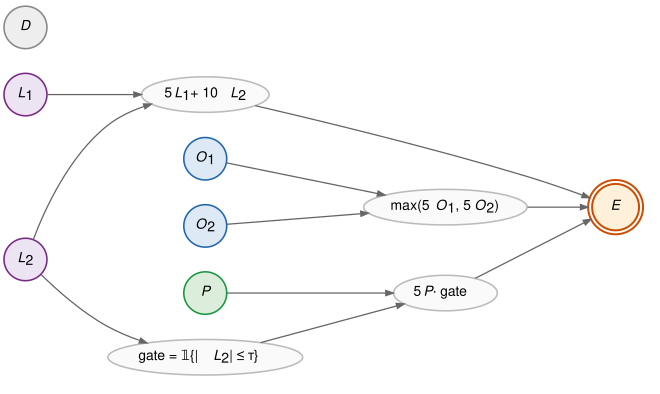

Wrote /home/rafal/s76projects/explainable_paper/figures/archetypes_dag.pdf
Wrote /home/rafal/s76projects/explainable_paper/figures/archetypes_dag.png


In [3]:
from pathlib import Path

# Locate project root so figures land at <repo>/figures regardless of where the notebook
# is executed from.


def _project_root():
    p = Path.cwd().resolve()
    for parent in [p] + list(p.parents):
        if (parent / "pyproject.toml").is_file():
            return parent
    return p


FIG_DIR = _project_root() / "figures"
FIG_DIR.mkdir(exist_ok=True)

# Archetype palette (mirrors the role-color scheme used in §5 of this notebook).
LIN_FILL, LIN_BORDER = "#ece4f2", "#762a83"  # purple — linear N+S
OD_FILL, OD_BORDER = "#dde9f5", "#2166ac"  # blue   — overdetermined
P_FILL, P_BORDER = "#dceddb", "#1a9641"  # green  — gated
D_FILL, D_BORDER = "#eeeeee", "#888888"  # grey   — irrelevant
M_FILL, M_BORDER = "#fafafa", "#bbbbbb"  # mediators
E_FILL, E_BORDER = "#fef0d9", "#cc4c02"  # outcome


def render_archetypes_dag():
    """Paper-quality DAG of the synthetic archetype model.
    Roots: circles, colored by archetype. Mediators: ellipses carrying their formulas.
    Outcome: orange double-circle. D has no outgoing edges (irrelevance control)."""
    g = graphviz.Digraph("archetypes", engine="dot")
    g.attr(
        rankdir="LR",
        bgcolor="white",
        margin="0.18",
        nodesep="0.35",
        ranksep="0.85",
        fontname="Helvetica",
    )
    g.attr(
        "node",
        fontname="Helvetica",
        fontsize="14",
        style="filled,rounded",
        penwidth="1.6",
    )
    g.attr("edge", color="#666666", penwidth="1.3", arrowsize="0.75")

    def root(name, label, fill, border):
        g.node(
            name,
            label=label,
            shape="circle",
            width="0.6",
            fixedsize="true",
            fillcolor=fill,
            color=border,
        )

    def mediator(name, label):
        g.node(
            name,
            label=label,
            shape="ellipse",
            fillcolor=M_FILL,
            color=M_BORDER,
            style="filled",
        )

    root("L1", "<<I>L</I><SUB>1</SUB>>", LIN_FILL, LIN_BORDER)
    root("L2", "<<I>L</I><SUB>2</SUB>>", LIN_FILL, LIN_BORDER)
    root("O1", "<<I>O</I><SUB>1</SUB>>", OD_FILL, OD_BORDER)
    root("O2", "<<I>O</I><SUB>2</SUB>>", OD_FILL, OD_BORDER)
    root("P", "<<I>P</I>>", P_FILL, P_BORDER)
    root("D", "<<I>D</I>>", D_FILL, D_BORDER)

    mediator("lin", "<5<I>L</I><SUB>1</SUB> + 10<I>L</I><SUB>2</SUB>>")
    mediator("od", "<max(5<I>O</I><SUB>1</SUB>, 5<I>O</I><SUB>2</SUB>)>")
    mediator("gate", "<gate = &#120793;{|<I>L</I><SUB>2</SUB>| &le; &tau;}>")
    mediator("p_branch", "<5<I>P</I> &middot; gate>")

    g.node(
        "E",
        "<<I>E</I>>",
        shape="doublecircle",
        width="0.65",
        fixedsize="true",
        fillcolor=E_FILL,
        color=E_BORDER,
        penwidth="2",
    )

    for src, dst in [
        ("L1", "lin"),
        ("L2", "lin"),
        ("O1", "od"),
        ("O2", "od"),
        ("L2", "gate"),
        ("gate", "p_branch"),
        ("P", "p_branch"),
        ("lin", "E"),
        ("od", "E"),
        ("p_branch", "E"),
    ]:
        g.edge(src, dst)

    return g


# Render in-notebook and bake to static files for the paper.
_g = render_archetypes_dag()
display(_g)
_out = FIG_DIR / "archetypes_dag"
_g.render(filename=str(_out), format="pdf", cleanup=True)
_g.render(filename=str(_out), format="png", cleanup=True)
print(f"Wrote {_out.with_suffix('.pdf')}")
print(f"Wrote {_out.with_suffix('.png')}")

## 2. Two factual cases

We pick two factual observations, one per regime, so every archetype is visible in at
least one of them.

### Case 1: preempted regime, contestable $O$ pair

Filter: $\lvert L_2 \rvert > \tau$ (gate off, $P$ branch zeroed) and $|O_1 - O_2| < \delta$
with $\delta = 1.0$.

The gate-off regime and the contestable pair go together because each targets a
different desideratum. Gate off means $P$ drops out of $E$ entirely, so this case serves as
the negative control for preemption: $P$ must drop to the noise floor (desiderata 8-9). In a
*contestable* $O$ pair neither $O_1$ nor $O_2$ reliably wins the max, so resampling either
one lets the partner take over about half the time.
Necessity should therefore come out close between them (desideratum 5), while sufficiency
still favours whichever one factually won (desideratum 3). A dominant winner would collapse
that between-variable symmetry test, so Case 2 uses one.

In [4]:
def factual_df(index=0):
    return pd.DataFrame(
        {k: v[index, 0, 0].numpy().flatten() for k, v in factual_dict.items()}
    )


def manual_E(df):
    L1, L2 = df["L1"].item(), df["L2"].item()
    O1, O2 = df["O1"].item(), df["O2"].item()
    P = df["P"].item()
    lin = 5 * L1 + 10 * L2
    od = max(5 * O1, 5 * O2)
    preempt = float(abs(L2) > TAU)
    p_branch = 5 * P * (1.0 - preempt)
    return lin + od + p_branch


DELTA = 1.0
case1_index = None
for i in range(n_size):
    df = factual_df(i)
    if df["preempt"].item() == 1.0 and abs(df["O1"].item() - df["O2"].item()) < DELTA:
        case1_index = i
        break

assert case1_index is not None, (
    "No observation matches the Case 1 filter; try a different seed or relax DELTA."
)

print(f"Case 1 observation index: {case1_index}")
print()
display(factual_df(case1_index))

df1 = factual_df(case1_index)
print(f"Manual E (recomputed by hand): {manual_E(df1):.4f}")
print(f"Model  E (read from sample):  {df1['E'].item():.4f}")

Case 1 observation index: 3



,L1,L2,O1,O2,P,D,lin,od,preempt,p_branch,E
0,-0.433879,-0.725759,1.303479,2.217562,-0.019205,-1.290702,-9.42698,11.087809,1.0,-0.0,1.660829


Manual E (recomputed by hand): 1.6608
Model  E (read from sample):  1.6608


### Case 2: unpreempted regime, dominant $O$ winner

Filter: $\lvert L_2 \rvert \le \tau$ (gate on, $P$ branch active) and $|O_1 - O_2| > \delta$.

The dominant winner makes the *within-variable* $S$-not-$N$ gap visible: the winner
is large enough that alternatives rarely beat it (high $S$), and the loser provides a partial
floor once we intervene on the winner (reduced $N$). A contestable pair cannot show this,
because pinning either one still leaves the partner free to flip the max.

The two cases together test the structural-role-not-identity claim: the same $P$ should land
at the noise floor in Case 1 and mirror $L_1$ in Case 2.

In [5]:
case2_index = None
for i in range(n_size):
    df = factual_df(i)
    if df["preempt"].item() == 0.0 and abs(df["O1"].item() - df["O2"].item()) > DELTA:
        case2_index = i
        break

assert case2_index is not None, (
    "No observation matches the Case 2 filter; try a different seed or relax DELTA."
)

print(f"Case 2 observation index: {case2_index}")
print()
display(factual_df(case2_index))

df2 = factual_df(case2_index)
print(f"Manual E (recomputed by hand): {manual_E(df2):.4f}")
print(f"Model  E (read from sample):  {df2['E'].item():.4f}")

Case 2 observation index: 7



,L1,L2,O1,O2,P,D,lin,od,preempt,p_branch,E
0,-2.115219,0.543095,0.535047,2.397251,-0.206175,0.926995,-5.145143,11.986256,0.0,-1.030874,5.810239


Manual E (recomputed by hand): 5.8102
Model  E (read from sample):  5.8102


### Predicted scores for each case

#### Case 1: gate off, contestable $O$ pair

| variable           | $ci_N$              | $ci_S$              | reason                                                |
|--------------------|---------------------|---------------------|-------------------------------------------------------|
| $L_1$              | moderate            | moderate            | linear, weight 5                                      |
| $L_2$              | high                | high                | linear, weight 10; also gates $P$                     |
| $O_\text{winner}$  | comparable to loser | above loser         | barely wins the max                                   |
| $O_\text{loser}$   | comparable to winner | below winner       | partner often beats it under resampling               |
| $P$                | ~0                  | ~0                  | gated off                                             |
| $D$                | ~0                  | ~0                  | not in $E$                                            |

#### Case 2: gate on, dominant $O$ winner

| variable           | $ci_N$              | $ci_S$              | reason                                                |
|--------------------|---------------------|---------------------|-------------------------------------------------------|
| $L_1$              | moderate            | moderate            | linear, weight 5                                      |
| $L_2$              | mid                 | mid                 | linear, weight 10, but $\lvert L_2 \rvert$ small now  |
| $O_\text{winner}$  | low                 | high                | within-variable $S \gg N$ shows up here              |
| $O_\text{loser}$   | ~0                  | ~0                  | dominated by the winner                               |
| $P$                | moderate            | moderate            | active, mirrors $L_1$                                 |
| $D$                | ~0                  | ~0                  | not in $E$                                            |

Both tables score every variable on two axes, $ci_N$ and $ci_S$, whose definitions come
next. Informally, $ci_N$ asks how much $E$ would have moved had the variable been
different (its necessity), and $ci_S$ asks how much the variable's actual value, on
its own, pins $E$ in place (its sufficiency). Section 3, next, defines both scores
precisely and derives them from the model; Section 4 then turns each
qualitative label above into a quantitative inequality on excess scores $\Delta_N, \Delta_S$
relative to $D$, with measured values and pass / fail.

In [6]:
suspect_names = ["L1", "L2", "O1", "O2", "P", "D"]

small_factual_dict = {k: factual_dict[k] for k in suspect_names + ["E"]}
factual_structured_dict = {"continuous": small_factual_dict, "categorical": {}}

searchable = SearchableModel(
    structured_model=synthetic_model_c,
    sites_of_interest=list(small_factual_dict.keys()),
    suspects=suspect_names,
    outcome_variable="E",
)

sampler = ThinSearchSampler(
    structured_model=searchable,
    conditioned_alternatives=True,
    factual_exclusion=True,
)

results = sampler.sample(
    factual_structured_dict,
    num_samples=num_search_samples,
)

  0%|          | 0/20000 [00:00<?, ?it/s]

  0%|          | 36/20000 [00:00<00:57, 347.85it/s]

  0%|          | 71/20000 [00:00<00:57, 346.95it/s]

  1%|          | 106/20000 [00:00<00:59, 334.52it/s]

  1%|          | 140/20000 [00:00<01:00, 330.44it/s]

...

100%|█████████▉| 19994/20000 [09:09<00:00, 13.53it/s]

100%|█████████▉| 19996/20000 [09:09<00:00, 13.69it/s]

100%|█████████▉| 19998/20000 [09:09<00:00, 13.81it/s]

100%|██████████| 20000/20000 [09:10<00:00, 13.81it/s]

100%|██████████| 20000/20000 [09:10<00:00, 36.36it/s]

## 3. PCI necessity and sufficiency

For each suspect $V$, PCI asks two separate counterfactual questions and turns each into its
own number.

`ThinSearchSampler` returns model outputs $E$ across two intervention regimes: a *necessity*
regime (intervene on $V$, set it to alternatives) and a *sufficiency* regime (pin $V$ at its
factual value, let everything else vary). Writing $e$ for $E$'s factual value,
`abs_diff_score` reads off:

- $ci_N = |E_\text{nec} - e|$ (necessity): how far $E$ moves when we *intervene* on $V$,
  away from its factual value. If $E$ barely budges, $V$ was not needed; the more $E$
  swings, the more necessary $V$ was.
- $ci_S = -|E_\text{suff} - e|$ (sufficiency): the (negated) distance $E$ drifts when
  we *pin* $V$ at factual and resample the other suspects. If pinning $V$ holds $E$
  near $e$ no matter what else happens, $V$'s value alone locks the outcome in, and the
  closer $ci_S$ is to zero, the more sufficient $V$ was.
- $\text{total} = ci_S + ci_N$ (the combined causal-impact score of Section *Causal impact*
  in the paper).

SHAP cannot separate these two numbers. The rest of the notebook checks that they line up
with the structural ground truth.


In [7]:
from typing import cast

cases = {"Case 1 (preempted)": case1_index, "Case 2 (unpreempted)": case2_index}

# score_lookup[case_label][var_name]   -> {"ci_N", "ci_S", "total"}      means only
# samples_lookup[case_label][var_name] -> {"nec", "suff", "total"}       per-sample arrays
# The per-sample arrays are needed for the bootstrap-derived threshold ε in Section 4.
score_lookup: dict[str, dict] = {label: {} for label in cases}
samples_lookup: dict[str, dict] = {label: {} for label in cases}

records = []
for v in suspect_names:
    conditioned = condition_on_interventional_regime(
        results_dictionary=cast(dict, results),
        reference_variable_names=[v],
        antecedent_regimes={v: True},
        witness_regimes={v: False},
    )

    e_nec = conditioned["regime_necessity"]["E"].detach()
    e_suff = conditioned["regime_sufficiency"]["E"].detach()
    factual_E = small_factual_dict["E"].detach()

    scores = abs_diff_score(
        factual_outcomes=factual_E,
        suff_outcomes=e_suff,
        nec_outcomes=e_nec,
    )

    row = {"variable": v}
    for case_label, idx in cases.items():
        nec_samples = scores["nec"][:, idx, 0, 0]
        suff_samples = scores["suff"][:, idx, 0, 0]
        total_samples = scores["total"][:, idx, 0, 0]
        ci_N = nec_samples.nanmean().item()
        ci_S = suff_samples.nanmean().item()
        total = total_samples.nanmean().item()
        row[f"ci_N | {case_label}"] = ci_N
        row[f"ci_S | {case_label}"] = ci_S
        row[f"total | {case_label}"] = total
        score_lookup[case_label][v] = {"ci_N": ci_N, "ci_S": ci_S, "total": total}
        samples_lookup[case_label][v] = {
            "nec": nec_samples.numpy(),
            "suff": suff_samples.numpy(),
            "total": total_samples.numpy(),
        }
    records.append(row)

scores_df = pd.DataFrame(records).set_index("variable")
display(scores_df.round(3))

,ci_N | Case 1 (preempted),ci_S | Case 1 (preempted),total | Case 1 (preempted),ci_N | Case 2 (unpreempted),ci_S | Case 2 (unpreempted),total | Case 2 (unpreempted)
variable,,,,,,
L1,8.882,-2.596,6.287,9.825,-3.401,6.425
L2,11.011,-1.513,9.498,10.467,-3.408,7.059
O1,8.250,-3.218,5.032,9.198,-4.645,4.553
O2,8.157,-2.871,5.286,9.385,-4.116,5.268
P,8.213,-3.236,4.977,9.558,-4.151,5.407
D,8.101,-3.382,4.718,9.308,-4.680,4.628


## 4. Desiderata

The raw $ci_N$ and $ci_S$ scores include a baseline picked up from co-intervening on the
other suspects, so even $D$, which never enters $E$, does not score exactly zero. To
correct for that, every claim below states the *excess* over $D$:

$$
\Delta_N(V; \text{case}) = ci_N(V; \text{case}) - ci_N(D; \text{case}),
\qquad
\Delta_S(V; \text{case}) = ci_S(V; \text{case}) - ci_S(D; \text{case}).
$$

A claim only counts as confirmed if it clears a margin wide enough that Monte Carlo
noise could not plausibly explain it. We derive that margin from the data: for every $\Delta_V$ we bootstrap the per-suspect score arrays,
resampling $V$ and $D$ jointly so their correlation survives, and read off a
standard error $\widehat{\sigma}(\Delta_V)$. The threshold is then

$$\epsilon \;=\; 1.645 \cdot \sigma_{\max}, \qquad
\sigma_{\max} = \max_V \widehat{\sigma}(\Delta_V),$$

the one-sided 95% quantile of a standard normal, times the largest bootstrap standard
error across every measured $\Delta$. Under the null hypothesis that the true effect is
zero, fewer than 5% of measurements would exceed this threshold by chance, so a $\Delta$
that clears $\epsilon$ reflects structure that sampling noise at this budget could not
produce. At `num_search_samples = 20000` this comes out to $\sigma_{\max} \approx 0.092$
and $\epsilon \approx 0.151$.

Ten of the archetype expectations from Section 2 become the numbered desiderata below:
directional claims about $\Delta_N$ or $\Delta_S$ that the structural model fixes in
advance, not something chosen after seeing the results. The table immediately below
states what each one checks and why it should hold, before any code runs. The cell after
it then computes every $\Delta$, derives $\epsilon$ as above, and evaluates each row. It
also reports two further comparisons, a cross-regime flip in $P$'s necessity and a
quantitative match between $P$ and $L_1$, as diagnostics, since neither clears
$\epsilon$ at this sample budget.

Each row pairs a causal intuition (why this effect should follow from how the
model wires the archetype) with the structural device that produces it, the
inequality on PCI's excess scores $\Delta_N$ and $\Delta_S$ that would confirm it, and
the check id evaluated in code below.

| # | intuition | structural device | formal desideratum | check id |
|---|---|---|---|---|
| 1 | The strongest linear N+S contributor should top necessity. Replacing $L_2$ shifts $E$ by ten times the difference; nothing substitutes for it. | additive term $5 L_1 + 10 L_2$ (Case 1) | $\Delta_N(L_2)$ is the largest | C1.L2_dominates_N |
| 2 | Same intuition, gate-on regime. | additive term $5 L_1 + 10 L_2$ (Case 2) | $\Delta_N(L_2)$ is the largest | C2.L2_dominates_N |
| 3 | Between-variable sufficiency asymmetry, regime-invariant: the max winner is more sufficient than the loser, because pinning the winner means alternatives rarely beat it, while pinning the loser lets the partner take over. | $\max(5 O_1, 5 O_2)$, contestable pair | $\Delta_S(O_w) - \Delta_S(O_l) > \epsilon$ | C1.O_sufficiency_asymmetry |
| 4 | Same intuition, dominant-winner pair. | $\max(5 O_1, 5 O_2)$, dominant winner | $\Delta_S(O_w) - \Delta_S(O_l) > \epsilon$ | C2.O_sufficiency_asymmetry |
| 5 | Within the contestable pair, neither variable strictly outranks the other on necessity, since overdetermination spreads necessity symmetrically when both contributors are close. | contestable $\max(5 O_1, 5 O_2)$ | $\lvert \Delta_N(O_w) - \Delta_N(O_l) \rvert < \epsilon$ | C1.O_necessity_symmetric |
| 6 | Within-variable $S$-not-$N$ signature, the local mark distinguishing PCI from SHAP. The winner is large enough that alternatives rarely beat it (high $\Delta_S$), and the loser provides a partial floor once we intervene on the winner (reduced $\Delta_N$). | $\max(5 O_1, 5 O_2)$, dominant winner | $\Delta_S(O_w) - \Delta_N(O_w) > \epsilon$ | C2.O_winner_S_exceeds_N |
| 7 | Linear is more necessary than overdetermined: the winner has an alternative path through the loser, so its necessity has a ceiling; $L_2$ has no such backup. | additive vs $\max$ comparison | $\Delta_N(L_2) - \Delta_N(O_w) > \epsilon$ | C2.L2_more_necessary_than_O_winner |
| 8 | Preemption zeroes a contributor: when the gate $\lvert L_2 \rvert > \tau$ is satisfied, $P$ does not enter $E$, so $P$ should drop to the noise floor on necessity. | gate $\mathbb{1}\{\lvert L_2 \rvert \le \tau\}$ off | $\lvert \Delta_N(P) \rvert < \epsilon$ | C1.P_at_noise_floor_N |
| 9 | Linear ranking by weight: $L_1$ has weight 5 like the active $P$, but in Case 1 $P$ is preempted, so $L_1$ should be more necessary. | weights $5 < 10$, gate off | $\Delta_N(L_1) - \Delta_N(P) > \epsilon$ | C1.L1_above_P_N |
| 10 | Regime change: when the gate is on, $P$ becomes a non-redundant linear contributor, so it should rise above the noise floor. | gate $\mathbb{1}\{\lvert L_2 \rvert \le \tau\}$ on | $\Delta_N(P) > \epsilon$ | C2.P_above_floor_N |

The cell below computes every measured value against these ten checks, plus two further
comparisons reported as diagnostics.

In [8]:
# Threshold from bootstrap: ε = 1.645 · σ_max (one-sided 95% on directional desiderata).
from typing import Any

import numpy as np

N_BOOT = 4000
SEED_BOOT = 0

case1_label = "Case 1 (preempted)"
case2_label = "Case 2 (unpreempted)"


def bootstrap_diff(arr_v, arr_d, n_boot=N_BOOT, seed=SEED_BOOT):
    """Bootstrap CI on nanmean(arr_v) − nanmean(arr_d) with shared resample indices,
    so per-sample correlation between V and D (both come from the same MC draws)
    is preserved."""
    rng = np.random.default_rng(seed)
    a = np.asarray(arr_v)
    d = np.asarray(arr_d)
    n = len(a)
    out = np.empty(n_boot)
    for k in range(n_boot):
        idx = rng.integers(0, n, size=n)
        out[k] = np.nanmean(a[idx]) - np.nanmean(d[idx])
    point = np.nanmean(a) - np.nanmean(d)
    return point, out.std(ddof=1), np.quantile(out, [0.025, 0.975])


def delta(samples, v, kind):
    return bootstrap_diff(samples[v][kind], samples["D"][kind])


def diff_of_deltas(samples, v1, k1, v2, k2):
    """Bootstrap CI on (Δ_{v1,k1}) − (Δ_{v2,k2})."""
    rng = np.random.default_rng(SEED_BOOT)
    a = np.asarray(samples[v1][k1])
    b = np.asarray(samples[v2][k2])
    d1 = np.asarray(samples["D"][k1])
    d2 = np.asarray(samples["D"][k2])
    n = len(a)
    out = np.empty(N_BOOT)
    for k in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        out[k] = (np.nanmean(a[idx]) - np.nanmean(d1[idx])) - (
            np.nanmean(b[idx]) - np.nanmean(d2[idx])
        )
    point = (np.nanmean(a) - np.nanmean(d1)) - (np.nanmean(b) - np.nanmean(d2))
    return point, out.std(ddof=1), np.quantile(out, [0.025, 0.975])


def cross_flip(samples1, samples2, v, kind):
    rng = np.random.default_rng(SEED_BOOT)
    a1 = np.asarray(samples1[v][kind])
    d1 = np.asarray(samples1["D"][kind])
    a2 = np.asarray(samples2[v][kind])
    d2 = np.asarray(samples2["D"][kind])
    n = min(len(a1), len(a2))
    out = np.empty(N_BOOT)
    for k in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        out[k] = (np.nanmean(a2[idx]) - np.nanmean(d2[idx])) - (
            np.nanmean(a1[idx]) - np.nanmean(d1[idx])
        )
    point = (np.nanmean(a2) - np.nanmean(d2)) - (np.nanmean(a1) - np.nanmean(d1))
    return point, out.std(ddof=1), np.quantile(out, [0.025, 0.975])


def winner_loser(case_idx):
    df = factual_df(case_idx)
    if 5 * df["O1"].item() >= 5 * df["O2"].item():
        return "O1", "O2"
    return "O2", "O1"


O_w_c1, O_l_c1 = winner_loser(case1_index)
O_w_c2, O_l_c2 = winner_loser(case2_index)

samples_c1 = samples_lookup[case1_label]
samples_c2 = samples_lookup[case2_label]

# σ_max across every Δ_V we will report (both cases, both kinds, all suspects ≠ D).
ses_all = []
for samples in (samples_c1, samples_c2):
    for v in suspect_names:
        if v == "D":
            continue
        for kind in ("nec", "suff"):
            _, se, _ = delta(samples, v, kind)
            ses_all.append(se)
sigma_max = max(ses_all)
EPS = round(1.645 * sigma_max, 3)
print(f"sigma_max across all Δ scores: {sigma_max:.4f}")
print(f"ε = 1.645 · sigma_max = {EPS:.3f}   (one-sided 95% threshold)")


def claim(
    num, case, label, claim_type, point, se, ci_lo, ci_hi, eps, formula
) -> dict[str, Any]:
    if claim_type == "above":
        passes = bool(point > eps)
    elif claim_type == "below_abs":
        passes = bool(abs(point) < eps)
    elif claim_type == "above_zero":
        passes = bool(point > 0)
    elif claim_type == "diagnostic":
        passes = None
    else:
        raise ValueError(claim_type)
    return {
        "num": num,
        "case": case,
        "claim": label,
        "formula": formula,
        "claim_type": claim_type,
        "measured": point,
        "se": se,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
        "eps": eps,
        "passes": passes,
    }


records = []

# ---- Case 1: preempted, contestable O ----
top_other_c1 = max(
    (v for v in suspect_names if v not in ("L2", "D")),
    key=lambda v: delta(samples_c1, v, "nec")[0],
)
p, se, ci = diff_of_deltas(samples_c1, "L2", "nec", top_other_c1, "nec")
records.append(
    claim(
        1,
        "C1",
        "ΔN(L2) is the largest excess necessity",
        "above_zero",
        p,
        se,
        ci[0],
        ci[1],
        0.0,
        "ΔN(L2) − max ΔN(other)",
    )
)

p, se, ci = diff_of_deltas(samples_c1, O_w_c1, "suff", O_l_c1, "suff")
records.append(
    claim(
        3,
        "C1",
        f"ΔS({O_w_c1}) − ΔS({O_l_c1}) > ε  (contestable)",
        "above",
        p,
        se,
        ci[0],
        ci[1],
        EPS,
        f"ΔS({O_w_c1}) − ΔS({O_l_c1})",
    )
)

p, se, ci = diff_of_deltas(samples_c1, O_w_c1, "nec", O_l_c1, "nec")
records.append(
    claim(
        5,
        "C1",
        f"|ΔN({O_w_c1}) − ΔN({O_l_c1})| < ε",
        "below_abs",
        p,
        se,
        ci[0],
        ci[1],
        EPS,
        f"ΔN({O_w_c1}) − ΔN({O_l_c1})",
    )
)

p, se, ci = delta(samples_c1, "P", "nec")
records.append(
    claim(
        8,
        "C1",
        "|ΔN(P)| < ε  (gate off)",
        "below_abs",
        p,
        se,
        ci[0],
        ci[1],
        EPS,
        "ΔN(P)",
    )
)

p, se, ci = diff_of_deltas(samples_c1, "L1", "nec", "P", "nec")
records.append(
    claim(
        9,
        "C1",
        "ΔN(L1) − ΔN(P) > ε",
        "above",
        p,
        se,
        ci[0],
        ci[1],
        EPS,
        "ΔN(L1) − ΔN(P)",
    )
)

# ---- Case 2: unpreempted, dominant O ----
top_other_c2 = max(
    (v for v in suspect_names if v not in ("L2", "D")),
    key=lambda v: delta(samples_c2, v, "nec")[0],
)
p, se, ci = diff_of_deltas(samples_c2, "L2", "nec", top_other_c2, "nec")
records.append(
    claim(
        2,
        "C2",
        "ΔN(L2) is the largest excess necessity",
        "above_zero",
        p,
        se,
        ci[0],
        ci[1],
        0.0,
        "ΔN(L2) − max ΔN(other)",
    )
)

p, se, ci = diff_of_deltas(samples_c2, O_w_c2, "suff", O_l_c2, "suff")
records.append(
    claim(
        4,
        "C2",
        f"ΔS({O_w_c2}) − ΔS({O_l_c2}) > ε  (dominant)",
        "above",
        p,
        se,
        ci[0],
        ci[1],
        EPS,
        f"ΔS({O_w_c2}) − ΔS({O_l_c2})",
    )
)

p, se, ci = diff_of_deltas(samples_c2, O_w_c2, "suff", O_w_c2, "nec")
records.append(
    claim(
        6,
        "C2",
        f"ΔS({O_w_c2}) − ΔN({O_w_c2}) > ε  (S-not-N)",
        "above",
        p,
        se,
        ci[0],
        ci[1],
        EPS,
        f"ΔS({O_w_c2}) − ΔN({O_w_c2})",
    )
)

p, se, ci = diff_of_deltas(samples_c2, "L2", "nec", O_w_c2, "nec")
records.append(
    claim(
        7,
        "C2",
        f"ΔN(L2) − ΔN({O_w_c2}) > ε",
        "above",
        p,
        se,
        ci[0],
        ci[1],
        EPS,
        f"ΔN(L2) − ΔN({O_w_c2})",
    )
)

p, se, ci = delta(samples_c2, "P", "nec")
records.append(
    claim(10, "C2", "ΔN(P) > ε  (gate on)", "above", p, se, ci[0], ci[1], EPS, "ΔN(P)")
)

# ---- Diagnostics (not numbered desiderata) ----
p, se, ci = cross_flip(samples_c1, samples_c2, "P", "nec")
records.append(
    claim(
        "D1",
        "diag",
        "ΔN(P, C2) − ΔN(P, C1)  (P role flip; CI typically straddles 0)",
        "diagnostic",
        p,
        se,
        ci[0],
        ci[1],
        EPS,
        "ΔN(P,C2) − ΔN(P,C1)",
    )
)

p, se, ci = diff_of_deltas(samples_c2, "P", "nec", "L1", "nec")
records.append(
    claim(
        "D2",
        "diag",
        "ΔN(P) − ΔN(L1), C2  (P does not quantitatively mirror L1)",
        "diagnostic",
        p,
        se,
        ci[0],
        ci[1],
        EPS,
        "ΔN(P) − ΔN(L1)",
    )
)

# ---- D-noise-floor drift (sanity report, not a desideratum) ----
raw_D_drift = abs(
    score_lookup[case1_label]["D"]["ci_N"] - score_lookup[case2_label]["D"]["ci_N"]
)
print(
    f"\nNoise-floor drift  |ci_N(D, C1) − ci_N(D, C2)| = {raw_D_drift:.3f}  (raw, not Δ-scaled)"
)
print(
    "  E's variance under co-interventions is structurally larger when the P branch is"
)
print(
    "  active (Case 2) than when it is gated off (Case 1); the raw scores reflect that."
)
print(
    "  Because every desideratum is stated on the excess Δ scores, this drift is absorbed."
)

desiderata_df = pd.DataFrame(records)


def fmt_pass(p):
    if p is None:
        return "—"
    return "PASS" if p else "FAIL"


display_df = desiderata_df.copy()
display_df["passes"] = display_df["passes"].apply(fmt_pass)
cols = ["num", "case", "claim", "measured", "se", "ci_lo", "ci_hi", "eps", "passes"]
display(display_df[cols].round(3))

n_pass = sum(1 for r in records if r["passes"] is True)
n_fail = sum(1 for r in records if r["passes"] is False)
n_diag = sum(1 for r in records if r["passes"] is None)
print(
    f"\nSummary: {n_pass} numbered desiderata pass, {n_fail} fail, {n_diag} diagnostics shown."
)

sigma_max across all Δ scores: 0.0919
ε = 1.645 · sigma_max = 0.151   (one-sided 95% threshold)



Noise-floor drift  |ci_N(D, C1) − ci_N(D, C2)| = 1.207  (raw, not Δ-scaled)
  E's variance under co-interventions is structurally larger when the P branch is
  active (Case 2) than when it is gated off (Case 1); the raw scores reflect that.
  Because every desideratum is stated on the excess Δ scores, this drift is absorbed.


,num,case,claim,measured,se,ci_lo,ci_hi,eps,passes
0,1,C1,ΔN(L2) is the largest excess necessity,2.129,0.088,1.953,2.300,0.000,PASS
1,3,C1,ΔS(O2) − ΔS(O1) > ε (contestable),0.347,0.065,0.216,0.473,0.151,PASS
2,5,C1,|ΔN(O2) − ΔN(O1)| < ε,-0.093,0.089,-0.266,0.081,0.151,PASS
3,8,C1,|ΔN(P)| < ε (gate off),0.112,0.088,-0.058,0.280,0.151,PASS
4,9,C1,ΔN(L1) − ΔN(P) > ε,0.670,0.089,0.499,0.843,0.151,PASS
5,2,C2,ΔN(L2) is the largest excess necessity,0.642,0.086,0.476,0.813,0.000,PASS
6,4,C2,ΔS(O2) − ΔS(O1) > ε (dominant),0.529,0.073,0.387,0.667,0.151,PASS
7,6,C2,ΔS(O2) − ΔN(O2) > ε (S-not-N),0.487,0.117,0.256,0.712,0.151,PASS
8,7,C2,ΔN(L2) − ΔN(O2) > ε,1.082,0.084,0.915,1.251,0.151,PASS
9,10,C2,ΔN(P) > ε (gate on),0.250,0.086,0.079,0.422,0.151,PASS



Summary: 10 numbered desiderata pass, 0 fail, 2 diagnostics shown.


### Reading the desiderata

All ten numbered desiderata pass at the bootstrap-derived threshold $\epsilon \approx
0.151$ computed above, from a run of `num_search_samples = 20000`; each row also
contains a bootstrap 95% confidence interval, shown both in the table above and in the
forest plot below.


The forest plot below summarises the experiment: one row per numbered desideratum,
putting PCI's measurement beside the structural claim it codifies.

Reading a row:

- The dot is the bootstrap point estimate of the relevant $\Delta$ score, a necessity or
  sufficiency *excess over the irrelevance control* $D$ (or a difference of two such
  excesses, for comparison claims); it is the number PCI actually measured.
- The horizontal bar is the dot's bootstrap 95% CI (4,000 resamples, joint across $V$
  and $D$ so the per-sample correlation survives). A tight bar means the measurement
  is well-resolved at this sample budget; a wide bar means it is noisy.
- The green band is the row's pass region, the set of $\Delta$ values that would confirm
  the row's structural claim given the data-derived threshold $\epsilon \approx 0.151$.
  Its shape depends on the claim: for a $\Delta > \epsilon$ claim the band runs from
  $\epsilon$ rightward, since the effect must clear the noise floor by a margin; for a
  "$\Delta_V$ is largest" comparison (rows 1, 2) it runs from $0$ rightward, since the
  plotted difference between $V$ and the next-largest suspect must be positive; and for
  a closeness claim like $|\Delta| < \epsilon$ (rows 5, 8) it is the strip $(-\epsilon,
  +\epsilon)$, since the effect must be indistinguishable from the floor, as expected
  for a preempted or symmetric variable.
- The formula or value column on the right names the exact quantity the dot represents
  and prints its measured value, colour-coded green for a pass or red for a fail.

A row passes when its dot falls inside the green band, and all ten do, so PCI
recovers every archetype's structural signature. The tightest is row 10
($\Delta_N(P) > \epsilon$ in Case 2, gate on): the point estimate $+0.250$ clears
$\epsilon \approx 0.151$ by roughly one $\sigma$, with its confidence interval's lower
edge at $+0.079$, still on the right side of zero, but the closest call on the plot. It is
the hardest claim to satisfy because it is the cross-regime test of structural role over
identity: the same variable $P$ that fell to the noise floor in Case 1 (gated off) now has
to register as a live linear contributor in Case 2 (gated on).

Two further comparisons, the cross-regime $P$ flip and the quantitative match of
$\Delta_N(P)$ to $\Delta_N(L_1)$ in Case 2, stay off the plot, because they do not clear
the bootstrap-derived threshold; the table above reports both as diagnostics.

The cell also saves the plot under `figures/archetypes_threshold_forest.png` for the
paper.

Wrote /home/rafal/s76projects/explainable_paper/figures/archetypes_threshold_forest.png


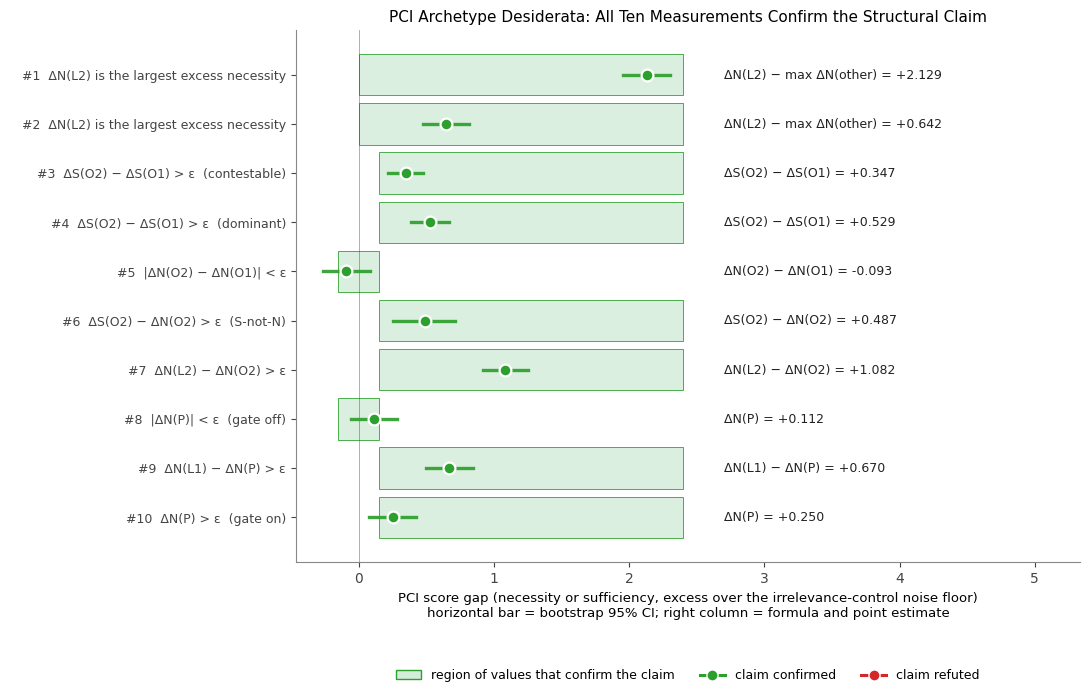

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle


def pass_region(claim_type, eps):
    """Interval of measured Δ values that confirm this claim."""
    if claim_type == "above":
        return (eps, 100.0)
    if claim_type == "above_zero":
        return (0.0, 100.0)
    if claim_type == "below_abs":
        return (-eps, eps)
    return None


# Drop diagnostics from the plot; they are reported in the table above for completeness.
plot_records: list[dict[str, Any]] = [
    r for r in records if r["claim_type"] != "diagnostic"
]

# Sort: numbered desiderata in claim-id order (#1..#10).


def _key(row):
    return int(row["num"])


ordered = sorted(plot_records, key=_key)
display_rows: list[dict[str, Any]] = [{"kind": "data", "row": r} for r in ordered]

# Per-claim formula label (what number the dot/bar represents).
formula_for = {}
for r in plot_records:
    formula_for[r["num"]] = r.get("formula", "")


def color_for(passes):
    if passes is None:
        return "#888888"
    return "#2ca02c" if passes else "#d62728"


# Layout: left = data area; right = formula+value column, fully separated.
import math

_finite_lo = [r["ci_lo"] for r in plot_records if math.isfinite(r["ci_lo"])]
_finite_hi = [r["ci_hi"] for r in plot_records if math.isfinite(r["ci_hi"])]
all_lo = min(_finite_lo) if _finite_lo else 0.0
all_hi = max(_finite_hi) if _finite_hi else 1.0
xpad = 0.20
xmin = all_lo - xpad
data_right = all_hi + 0.10
annotation_left = data_right + 0.30
annot_widths = [len(f"{r['formula']} = {r['measured']:+.3f}") for r in plot_records]
xmax = annotation_left + 0.085 * max(annot_widths)

n_rows = len(display_rows)
fig, ax = plt.subplots(figsize=(11.0, 0.55 * n_rows + 1.6))

PASS_FILL = "#d4edda"
PASS_EDGE = "#2ca02c"

for y, entry in enumerate(display_rows):
    r = entry["row"]
    pr = pass_region(r["claim_type"], r["eps"])
    if pr is not None:
        lo, hi = max(pr[0], xmin), min(pr[1], data_right)
        ax.add_patch(
            Rectangle(
                (lo, y - 0.42),
                hi - lo,
                0.84,
                facecolor=PASS_FILL,
                edgecolor=PASS_EDGE,
                linewidth=0.7,
                alpha=0.85,
                zorder=0,
            )
        )
    color = color_for(r["passes"])
    ax.plot(
        [r["ci_lo"], r["ci_hi"]],
        [y, y],
        color=color,
        linewidth=2.4,
        alpha=0.92,
        zorder=2,
    )
    ax.plot(
        [r["measured"]],
        [y],
        "o",
        color=color,
        markersize=8.5,
        markeredgecolor="white",
        markeredgewidth=1.6,
        zorder=3,
    )
    ax.text(
        annotation_left,
        y,
        f"{r['formula']} = {r['measured']:+.3f}",
        fontsize=9,
        color="#222",
        ha="left",
        va="center",
    )

ax.axvline(0, color="#444", linewidth=0.6, alpha=0.5, zorder=1)

ylabels = [
    f"   #{entry['row']['num']}  {entry['row']['claim']}" for entry in display_rows
]
ax.set_yticks(range(n_rows))
ax.set_yticklabels(ylabels, fontsize=9)
ax.invert_yaxis()

# Despine
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color("#888")
ax.spines["bottom"].set_color("#888")
ax.tick_params(colors="#444")

legend_handles = [
    Patch(
        facecolor=PASS_FILL,
        edgecolor=PASS_EDGE,
        label="region of values that confirm the claim",
    ),
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="#2ca02c",
        linewidth=2.2,
        markersize=8,
        markeredgecolor="white",
        label="claim confirmed",
    ),
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="#d62728",
        linewidth=2.2,
        markersize=8,
        markeredgecolor="white",
        label="claim refuted",
    ),
]
ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    fontsize=9,
    frameon=False,
)

ax.set_xlim(xmin, xmax)
ax.set_xlabel(
    "PCI score gap (necessity or sufficiency, excess over the irrelevance-control "
    "noise floor)\n"
    "horizontal bar = bootstrap 95% CI; right column = formula and point estimate",
    fontsize=9.5,
)
ax.set_title(
    "PCI Archetype Desiderata: All Ten Measurements Confirm the Structural Claim",
    fontsize=11,
)

plt.tight_layout()
out_path = FIG_DIR / "archetypes_threshold_forest.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Wrote {out_path}")
plt.show()

## 5. Marginal SHAP

PCI has given us two numbers per variable. What would a standard single-number attribution
say on the *same* model? We run SHAP next, then set the two side by side.

We use `shap.KernelExplainer` with a marginal background sampled from each feature's prior.
Because the prediction function is deterministic and the features are independent, this is
the standard setup for interventional-style SHAP here.

In [10]:
import shap

FEATURE_ORDER = ["L1", "L2", "O1", "O2", "P", "D"]


def predict_E(X):
    """Vectorised numpy reduction of synthetic_model_c. X: (n, 6) in FEATURE_ORDER."""
    L1 = X[:, 0]
    L2 = X[:, 1]
    O1 = X[:, 2]
    O2 = X[:, 3]
    P = X[:, 4]
    lin = 5.0 * L1 + 10.0 * L2
    od = np.maximum(5.0 * O1, 5.0 * O2)
    preempt = (np.abs(L2) > TAU).astype(float)
    p_branch = 5.0 * P * (1.0 - preempt)
    return lin + od + p_branch


def factual_x(case_idx):
    df = factual_df(case_idx)
    return df[FEATURE_ORDER].to_numpy().reshape(1, len(FEATURE_ORDER))


def manual_breakdown(x, expected_pyro=None):
    """Recompute E's exact arithmetic breakdown for one input row (quietly), and
    assert it agrees with the predict_E wrapper and, if given, the Pyro model."""
    L1, L2, O1, O2, P, D = x
    lin = 5.0 * L1 + 10.0 * L2
    od = max(5.0 * O1, 5.0 * O2)
    preempt = 1.0 if abs(L2) > TAU else 0.0
    p_branch = 5.0 * P * (1.0 - preempt)
    total = lin + od + p_branch

    wrapper_total = float(predict_E(np.asarray(x, dtype=float).reshape(1, -1))[0])
    assert np.isclose(total, wrapper_total, atol=1e-6), (
        f"manual {total} != wrapper {wrapper_total}"
    )
    if expected_pyro is not None:
        assert np.isclose(total, expected_pyro, atol=1e-6), (
            f"manual {total} != pyro {expected_pyro}"
        )
    return total


X_case1 = factual_x(case1_index)
X_case2 = factual_x(case2_index)
E_case1_pyro = small_factual_dict["E"][case1_index, 0, 0].item()
E_case2_pyro = small_factual_dict["E"][case2_index, 0, 0].item()

manual_breakdown(X_case1[0], expected_pyro=E_case1_pyro)
manual_breakdown(X_case2[0], expected_pyro=E_case2_pyro)
print(
    "predict_E (the numpy wrapper SHAP will call) agrees with the manual arithmetic "
    "and the Pyro model on both factual rows."
)

predict_E (the numpy wrapper SHAP will call) agrees with the manual arithmetic and the Pyro model on both factual rows.


In [11]:
# Marginal background: each feature drawn independently from its prior.
rng = np.random.default_rng(0)
n_bg = 200
background_marginal = np.column_stack(
    [
        rng.normal(0.0, 1.0, n_bg),  # L1
        rng.normal(0.0, 1.0, n_bg),  # L2
        rng.normal(1.0, 1.0, n_bg),  # O1
        rng.normal(1.0, 1.0, n_bg),  # O2
        rng.normal(0.0, 1.0, n_bg),  # P
        rng.normal(0.0, 1.0, n_bg),  # D
    ]
)

explainer = shap.KernelExplainer(predict_E, background_marginal)

# Compute SHAP values on both factual rows. nsamples="auto" fixes the coalition budget.
shap_c1 = explainer.shap_values(X_case1, nsamples=2000, silent=True).flatten()
shap_c2 = explainer.shap_values(X_case2, nsamples=2000, silent=True).flatten()

shap_table = pd.DataFrame(
    {"SHAP | Case 1": shap_c1, "SHAP | Case 2": shap_c2},
    index=FEATURE_ORDER,
)
shap_table.index.name = "variable"
display(shap_table.round(3))
print(f"E[f] (marginal background): {explainer.expected_value:+.4f}")
print(
    f"Sum SHAP + E[f], Case 1:    {shap_c1.sum() + explainer.expected_value:+.4f}  vs  factual {E_case1_pyro:+.4f}"
)
print(
    f"Sum SHAP + E[f], Case 2:    {shap_c2.sum() + explainer.expected_value:+.4f}  vs  factual {E_case2_pyro:+.4f}"
)

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


,SHAP | Case 1,SHAP | Case 2
variable,,
L1,-2.246,-10.652
L2,-6.293,5.766
O1,-0.101,-0.988
O2,3.383,5.169
P,0.034,-0.368
D,0.000,0.000


E[f] (marginal background): +6.8837
Sum SHAP + E[f], Case 1:    +1.6608  vs  factual +1.6608
Sum SHAP + E[f], Case 2:    +5.8102  vs  factual +5.8102


## 6. Causal SHAP

Causal / interventional SHAP (Heskes and Janzing) replaces empirical conditioning with a
do-intervention on the SCM:

$$
v(S) = \mathbb{E}\big[f(X) \,\big|\, \mathrm{do}(X_S = x_S^\star)\big]
\;=\; \mathbb{E}_{X_{-S} \sim P(X_{-S} \,|\, \mathrm{do}(X_S = x_S^\star))}[\, f(x_S^\star, X_{-S}) \,].
$$

The standard formula then computes Shapley values exactly from $v$. With six
features the coalition lattice has $2^6 = 64$ subsets, small enough to enumerate.

In this model the SCM has independent roots, so
$P(X_{-S} \,|\, \mathrm{do}(X_S = x_S^\star)) = P(X_{-S})$, and causal SHAP should coincide
with marginal SHAP up to Monte-Carlo noise. We run it explicitly anyway: doing so documents
the method, provides infrastructure for a non-flat causal variant later, and verifies the
equivalence empirically.

In [12]:
import math
from itertools import combinations

# Per-feature priors used by the SCM (independent across roots).
PRIOR_LOC = np.array([0.0, 0.0, 1.0, 1.0, 0.0, 0.0])
PRIOR_SCALE = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
N_FEATURES = len(FEATURE_ORDER)


def sample_post_intervention(coalition, x_factual, n_mc, rng):
    """Sample (n_mc, 6) rows where coalition features are pinned at factual,
    off-coalition features are drawn from their prior (post-do distribution
    for independent roots)."""
    X = rng.normal(loc=PRIOR_LOC, scale=PRIOR_SCALE, size=(n_mc, N_FEATURES))
    for i in coalition:
        X[:, i] = x_factual[i]
    return X


def value_function(coalition, x_factual, n_mc, rng):
    """v(S) = E[f(X) | do(X_S = x_S*)]"""
    X = sample_post_intervention(coalition, x_factual, n_mc, rng)
    return predict_E(X).mean()


def causal_shap(x_factual, n_mc=4000, seed=0):
    """Exact Shapley values with do-intervention value function v(S).
    Enumerates all 2^N_FEATURES coalitions; v(S) is MC-estimated with n_mc samples each."""
    rng = np.random.default_rng(seed)
    # Memoise v over all subsets.
    all_subsets = []
    for r in range(N_FEATURES + 1):
        all_subsets.extend(frozenset(s) for s in combinations(range(N_FEATURES), r))
    v_cache = {S: value_function(S, x_factual, n_mc, rng) for S in all_subsets}

    n = N_FEATURES
    phi = np.zeros(n)
    for i in range(n):
        for r in range(n):
            for S_tuple in combinations([j for j in range(n) if j != i], r):
                S = frozenset(S_tuple)
                w = math.factorial(r) * math.factorial(n - r - 1) / math.factorial(n)
                phi[i] += w * (v_cache[S | {i}] - v_cache[S])
    return phi, v_cache[frozenset()]  # also return v(empty) = baseline


cshap_c1, baseline_c1 = causal_shap(X_case1[0])
cshap_c2, baseline_c2 = causal_shap(X_case2[0])

cshap_table = pd.DataFrame(
    {"cSHAP | Case 1": cshap_c1, "cSHAP | Case 2": cshap_c2},
    index=FEATURE_ORDER,
)
cshap_table.index.name = "variable"
display(cshap_table.round(3))

print(f"v(empty) baseline,  Case 1: {baseline_c1:+.4f}    Case 2: {baseline_c2:+.4f}")
print(
    f"Sum cSHAP + v(empty), Case 1: {cshap_c1.sum() + baseline_c1:+.4f}  vs factual {E_case1_pyro:+.4f}"
)
print(
    f"Sum cSHAP + v(empty), Case 2: {cshap_c2.sum() + baseline_c2:+.4f}  vs factual {E_case2_pyro:+.4f}"
)

# Empirical equivalence check: cSHAP ≈ marginal SHAP on this model (independent roots).
diff_c1 = np.abs(cshap_c1 - shap_c1)
diff_c2 = np.abs(cshap_c2 - shap_c2)
print()
print("Max |cSHAP - SHAP| per case (expected small — independent roots):")
print(f"  Case 1: {diff_c1.max():.4f}")
print(f"  Case 2: {diff_c2.max():.4f}")

,cSHAP | Case 1,cSHAP | Case 2
variable,,
L1,-2.219,-10.629
L2,-7.308,5.104
O1,-0.106,-0.960
O2,3.403,5.169
P,-0.102,-0.861
D,0.019,0.013


v(empty) baseline,  Case 1: +7.9736    Case 2: +7.9736
Sum cSHAP + v(empty), Case 1: +1.6608  vs factual +1.6608
Sum cSHAP + v(empty), Case 2: +5.8102  vs factual +5.8102

Max |cSHAP - SHAP| per case (expected small — independent roots):
  Case 1: 1.0149
  Case 2: 0.6619


## 7. Comparison table

The table below lines up every number in one place: PCI's raw $ci_N$, $ci_S$, and total;
PCI's excess $\Delta_N$, $\Delta_S$ and the within-variable gap $\Delta_S - \Delta_N$;
marginal SHAP $\varphi$; and causal SHAP $\varphi$. The column to watch is
$\Delta_S - \Delta_N$, the overdetermination signature with no SHAP counterpart.

In [13]:
# Side-by-side comparison: PCI ci_N, ci_S, total vs SHAP (marginal) vs cSHAP (interventional).
# Excess scores Δ_N, Δ_S relative to D are also shown — these are what the qualitative
# checks read against.
def comparison_for_case(case_label, case_idx, shap_values, cshap_values):
    rows = []
    for i, v in enumerate(FEATURE_ORDER):
        ci_N = score_lookup[case_label][v]["ci_N"]
        ci_S = score_lookup[case_label][v]["ci_S"]
        total = score_lookup[case_label][v]["total"]
        d_N = ci_N - score_lookup[case_label]["D"]["ci_N"]
        d_S = ci_S - score_lookup[case_label]["D"]["ci_S"]
        rows.append(
            {
                "variable": v,
                "PCI ci_N": ci_N,
                "PCI ci_S": ci_S,
                "PCI total": total,
                "PCI Δ_N (excess)": d_N,
                "PCI Δ_S (excess)": d_S,
                "PCI Δ_S - Δ_N": d_S - d_N,
                "SHAP φ": shap_values[i],
                "cSHAP φ": cshap_values[i],
            }
        )
    df = pd.DataFrame(rows).set_index("variable").round(3)
    return df


comp_c1 = comparison_for_case(case1_label, case1_index, shap_c1, cshap_c1)
comp_c2 = comparison_for_case(case2_label, case2_index, shap_c2, cshap_c2)

print(f"=== {case1_label} ===")
display(comp_c1)
print()
print(f"=== {case2_label} ===")
display(comp_c2)

=== Case 1 (preempted) ===


,PCI ci_N,PCI ci_S,PCI total,PCI Δ_N (excess),PCI Δ_S (excess),PCI Δ_S - Δ_N,SHAP φ,cSHAP φ
variable,,,,,,,,
L1,8.882,-2.596,6.287,0.781,0.787,0.006,-2.246,-2.219
L2,11.011,-1.513,9.498,2.910,1.869,-1.041,-6.293,-7.308
O1,8.250,-3.218,5.032,0.149,0.164,0.016,-0.101,-0.106
O2,8.157,-2.871,5.286,0.056,0.511,0.455,3.383,3.403
P,8.213,-3.236,4.977,0.112,0.147,0.035,0.034,-0.102
D,8.101,-3.382,4.718,0.000,0.000,0.000,0.000,0.019



=== Case 2 (unpreempted) ===


,PCI ci_N,PCI ci_S,PCI total,PCI Δ_N (excess),PCI Δ_S (excess),PCI Δ_S - Δ_N,SHAP φ,cSHAP φ
variable,,,,,,,,
L1,9.825,-3.401,6.425,0.517,1.280,0.763,-10.652,-10.629
L2,10.467,-3.408,7.059,1.159,1.273,0.114,5.766,5.104
O1,9.198,-4.645,4.553,-0.110,0.035,0.145,-0.988,-0.960
O2,9.385,-4.116,5.268,0.077,0.564,0.487,5.169,5.169
P,9.558,-4.151,5.407,0.250,0.529,0.279,-0.368,-0.861
D,9.308,-4.680,4.628,0.000,0.000,0.000,0.000,0.013


## 8. Reading the comparison

SHAP gives each feature one number: its Shapley-weighted share of the prediction's distance
from a baseline (here the population mean). On this model that number gets the broad
picture right: it ranks the features sensibly, its magnitudes track PCI's, and the marginal
and causal variants coincide because the roots are independent. It cannot express the
distinction PCI rests on. Necessity asks whether a feature was *needed*; sufficiency asks
whether its value *alone* was enough. These two questions come apart exactly under
overdetermination and preemption, the patterns in this model, so compressing them into one
scalar discards the structure that matters: SHAP can rank causes, and it has no way to say
that a cause was dispensable and still sufficient, the combination overdetermination
consists in.

Consider $L_1$ (linear N+S, weight 5) and $O_2$ (overdetermined) in Case 2:

|        | SHAP $\varphi$ | cSHAP $\varphi$ | PCI $\Delta_N$ | PCI $\Delta_S$ | $\Delta_S - \Delta_N$ |
|--------|---------------:|----------------:|---------------:|---------------:|----------------------:|
| $L_1$  |   $-10.65$     |    $-10.63$     |   $+0.52$      |   $+1.28$      |   $+0.76$             |
| $O_2$  |    $+5.17$     |     $+5.17$     |   $+0.08$      |   $+0.56$      |   $+0.49$             |

Each SHAP variant gives one number per feature: $L_1$'s contribution is about twice the
magnitude of $O_2$'s, and nothing more. PCI adds a second coordinate, the
necessity axis, which separates the two archetypes. $L_1$ is both necessary and
sufficient, with necessity $\Delta_N = +0.52$ well above the $D$ noise floor. $O_2$'s
necessity $\Delta_N = +0.08$ falls *at* that floor: intervene on $O_2$ and its partner $O_1$
takes over the $\max$, so $O_2$ was hardly needed. Yet its sufficiency $\Delta_S = +0.56$ is
substantial, because $O_2$'s factual value alone was enough to pin the branch. That
combination, sufficient without being necessary, is overdetermination, recorded here as
the $\Delta_S - \Delta_N = +0.49$ signature of desideratum #6.

SHAP's single $+5.17$ for $O_2$ cannot register any of this; the same $+5.17$ could equally
describe a feature that was squarely necessary. The necessity coordinate is structurally
absent from a one-dimensional attribution, whether its value function is conditional,
marginal, or interventional, and no arithmetic on $\varphi(L_1)$ and $\varphi(O_2)$ recovers
it.

## 9. Reference points: the mean and the realized outcome

Case 1 and Case 2 differ in two ways at once: the feature *values* change, and the causal
*structure* changes with them (the gate that switches $P$ on or off flips between the two
cases). So when SHAP and PCI disagree across the two cases, we cannot yet tell whether
that disagreement tracks the changing values or the changing structure.

To isolate the values alone, we build a third instance where the structure stays fixed and
only the values move: we set every suspect to its own prior mean, the single most
"ordinary" input the model could see.

SHAP explains a prediction by measuring its distance from the typical case, so when every
feature already has its typical value the prediction *is* the typical case, and SHAP's
attribution budget comes out almost empty. PCI asks a different question: does re-drawing
this feature still move the outcome? That question has an answer whether or not the feature
happens to be at its mean, so PCI keeps registering structure once SHAP has
nothing left to attribute.

In [14]:
# Every suspect at its prior mean. The additive drivers (L1, L2, P) then sit exactly on the
# baseline SHAP references, so they add nothing to its budget f(x*) - E[f(X)]; PCI, tied to
# the realized outcome, still moves when we re-roll them. A light sample budget suffices here:
# the gap between the two methods is large, not a threshold call.
import numpy as np

means = {"L1": 0.0, "L2": 0.0, "O1": 1.0, "O2": 1.0, "P": 0.0, "D": 0.0}
K_mean = 8 if smoke_test else 24
nss_mean = 10 if smoke_test else 2000

E_mean = float(predict_E(np.array([[means[k] for k in FEATURE_ORDER]]))[0])
mean_dict = {k: torch.full((K_mean, 1, 1), float(means[k])) for k in suspect_names}
mean_dict["E"] = torch.full((K_mean, 1, 1), E_mean)


def all_means_model(
    kwargs_iterable=[{"observations_dict": None, "n_size": K_mean}, dict(), dict()],
):
    return synthetic_model_c(kwargs_iterable=kwargs_iterable)


searchable_mean = SearchableModel(
    structured_model=all_means_model,
    sites_of_interest=list(mean_dict.keys()),
    suspects=suspect_names,
    outcome_variable="E",
)
sampler_mean = ThinSearchSampler(
    structured_model=searchable_mean,
    conditioned_alternatives=True,
    factual_exclusion=True,
)
pyro.set_rng_seed(0)
results_mean = sampler_mean.sample(
    {"continuous": mean_dict, "categorical": {}}, num_samples=nss_mean
)


def mean_excess(var):
    conditioned = condition_on_interventional_regime(
        results_dictionary=cast(dict, results_mean),
        reference_variable_names=[var],
        antecedent_regimes={var: True},
        witness_regimes={var: False},
    )
    s = abs_diff_score(
        factual_outcomes=mean_dict["E"].detach(),
        suff_outcomes=conditioned["regime_sufficiency"]["E"].detach(),
        nec_outcomes=conditioned["regime_necessity"]["E"].detach(),
    )
    return (
        torch.nanmean(s["nec"][:, :, 0, 0]).item(),
        torch.nanmean(s["suff"][:, :, 0, 0]).item(),
    )


raw_mean = {v: mean_excess(v) for v in suspect_names}
shap_mean = explainer.shap_values(
    np.array([[means[k] for k in FEATURE_ORDER]]), nsamples=2000, silent=True
).flatten()

mean_table = pd.DataFrame(
    [
        {
            "variable": v,
            "SHAP φ": shap_mean[i],
            "PCI Δ_N": raw_mean[v][0] - raw_mean["D"][0],
            "PCI Δ_S": raw_mean[v][1] - raw_mean["D"][1],
        }
        for i, v in enumerate(FEATURE_ORDER)
    ]
).set_index("variable")

print(
    f"all-means instance:  E(x*) = {E_mean:.3f}   "
    f"E[f(X)] = {explainer.expected_value:+.3f}   "
    f"SHAP budget f(x*) - E[f(X)] = {E_mean - explainer.expected_value:+.3f}"
)
display(mean_table.round(3))

  0%|          | 0/2000 [00:00<?, ?it/s]

  2%|▏         | 39/2000 [00:00<00:05, 387.31it/s]

  4%|▍         | 79/2000 [00:00<00:04, 388.71it/s]

  6%|▌         | 118/2000 [00:00<00:04, 385.38it/s]

  8%|▊         | 157/2000 [00:00<00:04, 386.08it/s]

...

 97%|█████████▋| 1949/2000 [00:05<00:00, 361.91it/s]

 99%|█████████▉| 1986/2000 [00:05<00:00, 361.20it/s]

100%|██████████| 2000/2000 [00:05<00:00, 370.49it/s]

all-means instance:  E(x*) = 5.000   E[f(X)] = +6.884   SHAP budget f(x*) - E[f(X)] = -1.884


,SHAP φ,PCI Δ_N,PCI Δ_S
variable,,,
L1,-0.076,0.621,0.251
L2,0.603,2.086,1.088
O1,-1.417,0.370,0.132
O2,-1.389,0.341,0.210
P,0.395,0.670,0.360
D,0.000,0.000,0.000


At the all-means instance, the prediction is $E(x^\star) = 5.00$, almost exactly the
population baseline $\mathbb{E}[f(X)] \approx 6.88$ that SHAP measures against, so SHAP
has a total budget of only $-1.88$ to hand out across all six features.

$L_2$ illustrates this directly. It is the single most necessary variable in the entire
model (its weight, 10, is twice that of any other root), yet at this instance SHAP assigns
it just $0.60$, down from $5.77$ in Case 2, because $L_2$ now equals its own mean. $L_1$
and $P$ collapse the same way, to $-0.08$ and $0.40$. Only $O_1$ and $O_2$ keep any real
SHAP weight (about $-1.4$ each), because the $\max$ they feed into is nonlinear and so
leaves a residual even when both of its inputs equal their means.

PCI does not collapse. Re-drawing $L_2$ still moves the realized outcome by as much as it
always did, so its excess necessity stays at $\Delta_N = 2.09$, still the largest score in
the table and well clear of the $\epsilon \approx 0.15$ floor. $L_1$ and $P$ clear the
floor too, at $0.62$ and $0.67$.

| variable | SHAP $\varphi$ | PCI $\Delta_N$ | PCI $\Delta_S$ |
|---|---:|---:|---:|
| $L_1$ | $-0.08$ | $+0.62$ | $+0.25$ |
| $L_2$ | $+0.60$ | $+2.09$ | $+1.09$ |
| $O_1$ | $-1.42$ | $+0.37$ | $+0.13$ |
| $O_2$ | $-1.39$ | $+0.34$ | $+0.21$ |
| $P$   | $+0.40$ | $+0.67$ | $+0.36$ |
| $D$   | $0.00$  | $0.00$  | $0.00$  |

$L_2$'s SHAP value ($+0.60$) and its PCI necessity ($+2.09$) describe the same variable, at
the same instance, and disagree by more than a factor of three. SHAP measures how unusual
an input was, and at the mean nothing is unusual. PCI measures whether a variable still
drives the outcome, and for $L_2$ that has not changed.

## 10. Conclusions

- PCI recovers every archetype's structural profile. On a single SCM that mixes linear,
  overdetermined, and preempted contributions, all ten directional desiderata pass at a
  data-derived threshold $\epsilon$. The forest plot shows this directly: every one of
  the ten dots falls inside its pass band.
- SHAP cannot give this decomposition. SHAP (marginal and causal) agrees with PCI on
  rankings and magnitudes, and the two SHAP variants agree with each other, as theory
  predicts for independent roots. SHAP cannot report that $O_2$ is sufficient without
  being necessary, with necessity at the noise floor and sufficiency well above it: the $\Delta_S - \Delta_N = +0.49$ signature of overdetermination that no single
  $\varphi$ encodes.
- PCI scores structural role, which one variable can change between cases. The same $P$
  falls to the noise floor when its gate is off (Case 1) and registers as a live linear
  contributor when the gate is on (Case 2), because PCI scores the role the structure
  assigns it in each case.
- Reference points separate the methods too (Section 9). Putting every suspect at its own
  prior mean empties SHAP's attribution budget, since the prediction then equals the
  population baseline it decomposes and nothing remains to distribute, while PCI still
  registers causal structure, because re-rolling a feature still moves the realized
  outcome whatever the feature's value. The
  paper's signal-mediation baseline instance shows the same collapse.
- Always score excess over an irrelevance control. The raw $ci_N, ci_S$ include a
  regime-dependent co-intervention baseline that survives even for the unused variable
  $D$. Subtracting $D$ within each case ($\Delta_N, \Delta_S$) makes the archetype
  patterns read stably across regimes.

## Notes

Open threads:

- A model variant with non-flat causal structure (e.g. $L_1 \to$ some downstream feature) so
  causal SHAP and marginal SHAP diverge. On the model as defined they coincide, which makes
  that distinction invisible here.
- Scaling to a 500-observation batch: the PCI scoring loop is already vectorised over the
  batch dimension, so this is a sample-count change.